# Bloque 4 — Integración final

Lee los productos de los bloques 1–3 desde disco, verifica su coherencia, genera figuras finales, la tabla final, el reporte y la presentación.

In [1]:
# Localiza la raíz del repositorio (local o Kaggle) y la añade a sys.path.
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/SarahVasquezM/ksvd-image-denoising.git"
REPO_REF = os.environ.get("KSVD_REPO_REF", "codex/auditoria-final")

def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "modelo.py").exists():
            return p
    if Path("/kaggle/working").exists():          # Kaggle: clonar el repositorio
        dest = Path("/kaggle/working/ksvd-image-denoising")
        if not dest.exists():
            subprocess.run(["git", "clone", "--depth", "1", "--branch", REPO_REF,
                            REPO_URL, str(dest)], check=True)
        return dest
    raise FileNotFoundError("No se encontró la raíz del repositorio")

ROOT = find_root()
sys.path.insert(0, str(ROOT))
import warnings
# Mostrar advertencias sin rutas absolutas de la máquina (no se suprime ninguna).
warnings.formatwarning = lambda msg, cat, filename, lineno, line=None: (
    f"{cat.__name__} ({Path(filename).name}:{lineno}): {msg}\n")
from threadpoolctl import threadpool_limits
from src.pipeline import DEFAULT_THREADS, paths
threadpool_limits(limits=DEFAULT_THREADS)     # evita sobresuscripción BLAS con matrices pequeñas
P = paths(ROOT)
print("Raíz del repositorio:", ROOT.name)

Raíz del repositorio: ksvd-auditoria-final


## 1. Verificación de integración

In [2]:
import json, pandas as pd
from src.pipeline import run_block4
out = run_block4(ROOT)
print(json.dumps(out["checks"], indent=2))

{
  "D_shape": [
    64,
    128
  ],
  "K_matches_effective_config": true,
  "K_matches_results": true,
  "A_train_reproducible": true,
  "history_rows_match_n_iter": true,
  "test_image_matches": true,
  "eval_sparsities_present": true,
  "contingency_level": 0
}


## 2. Tabla final

In [3]:
out["table"]

,case_id,input_kind,method,sigma,condition,T0,mse,psnr_db,mean_active_coefs,max_active_coefs,reconstruction_time_s,coding_time_s,n_patches,n_atoms,max_nonzero,mean_nonzero,reconstruction_s,noise_seed
0,noisy_baseline,noisy,identity,0.078431,ruidosa_sin_procesar,0,0.006179,22.090880,NaN,NaN,NaN,NaN,NaN,128,0,NaN,NaN,44
1,clean_t2,clean,ksvd,0.078431,limpia,2,0.002132,26.712990,2.0,2.0,0.052232,0.042158,961.0,128,2,2.0,0.052232,44
2,clean_t4,clean,ksvd,0.078431,limpia,4,0.001264,28.982603,4.0,4.0,0.088511,0.080153,961.0,128,4,4.0,0.088511,44
3,clean_t8,clean,ksvd,0.078431,limpia,8,0.000719,31.430905,8.0,8.0,0.179354,0.163873,961.0,128,8,8.0,0.179354,44
4,noisy_t2,noisy,ksvd,0.078431,ruidosa,2,0.002784,25.553827,2.0,2.0,0.051862,0.043872,961.0,128,2,2.0,0.051862,44
5,noisy_t4,noisy,ksvd,0.078431,ruidosa,4,0.002442,26.121743,4.0,4.0,0.093958,0.082747,961.0,128,4,4.0,0.093958,44
6,noisy_t8,noisy,ksvd,0.078431,ruidosa,8,0.002730,25.638454,8.0,8.0,0.168103,0.160086,961.0,128,8,8.0,0.168103,44


## 3. Configuración efectiva y contingencias

In [4]:
eff = json.loads(P["config_efectiva"].read_text(encoding="utf-8"))
{k: eff[k] for k in ("contingency_level", "contingency_label", "overcomplete", "n_atoms", "n_train_patches",
                     "n_iter", "training_time_s", "train_mse_init_dictionary", "train_mse_final_recoded")}

{'contingency_level': 0,
 'contingency_label': 'configuración deseada',
 'overcomplete': True,
 'n_atoms': 128,
 'n_train_patches': 1500,
 'n_iter': 8,
 'training_time_s': 2.0895495000004303,
 'train_mse_init_dictionary': 0.000954902109100754,
 'train_mse_final_recoded': 0.00034132384459536715}

## 4. Figura-resumen

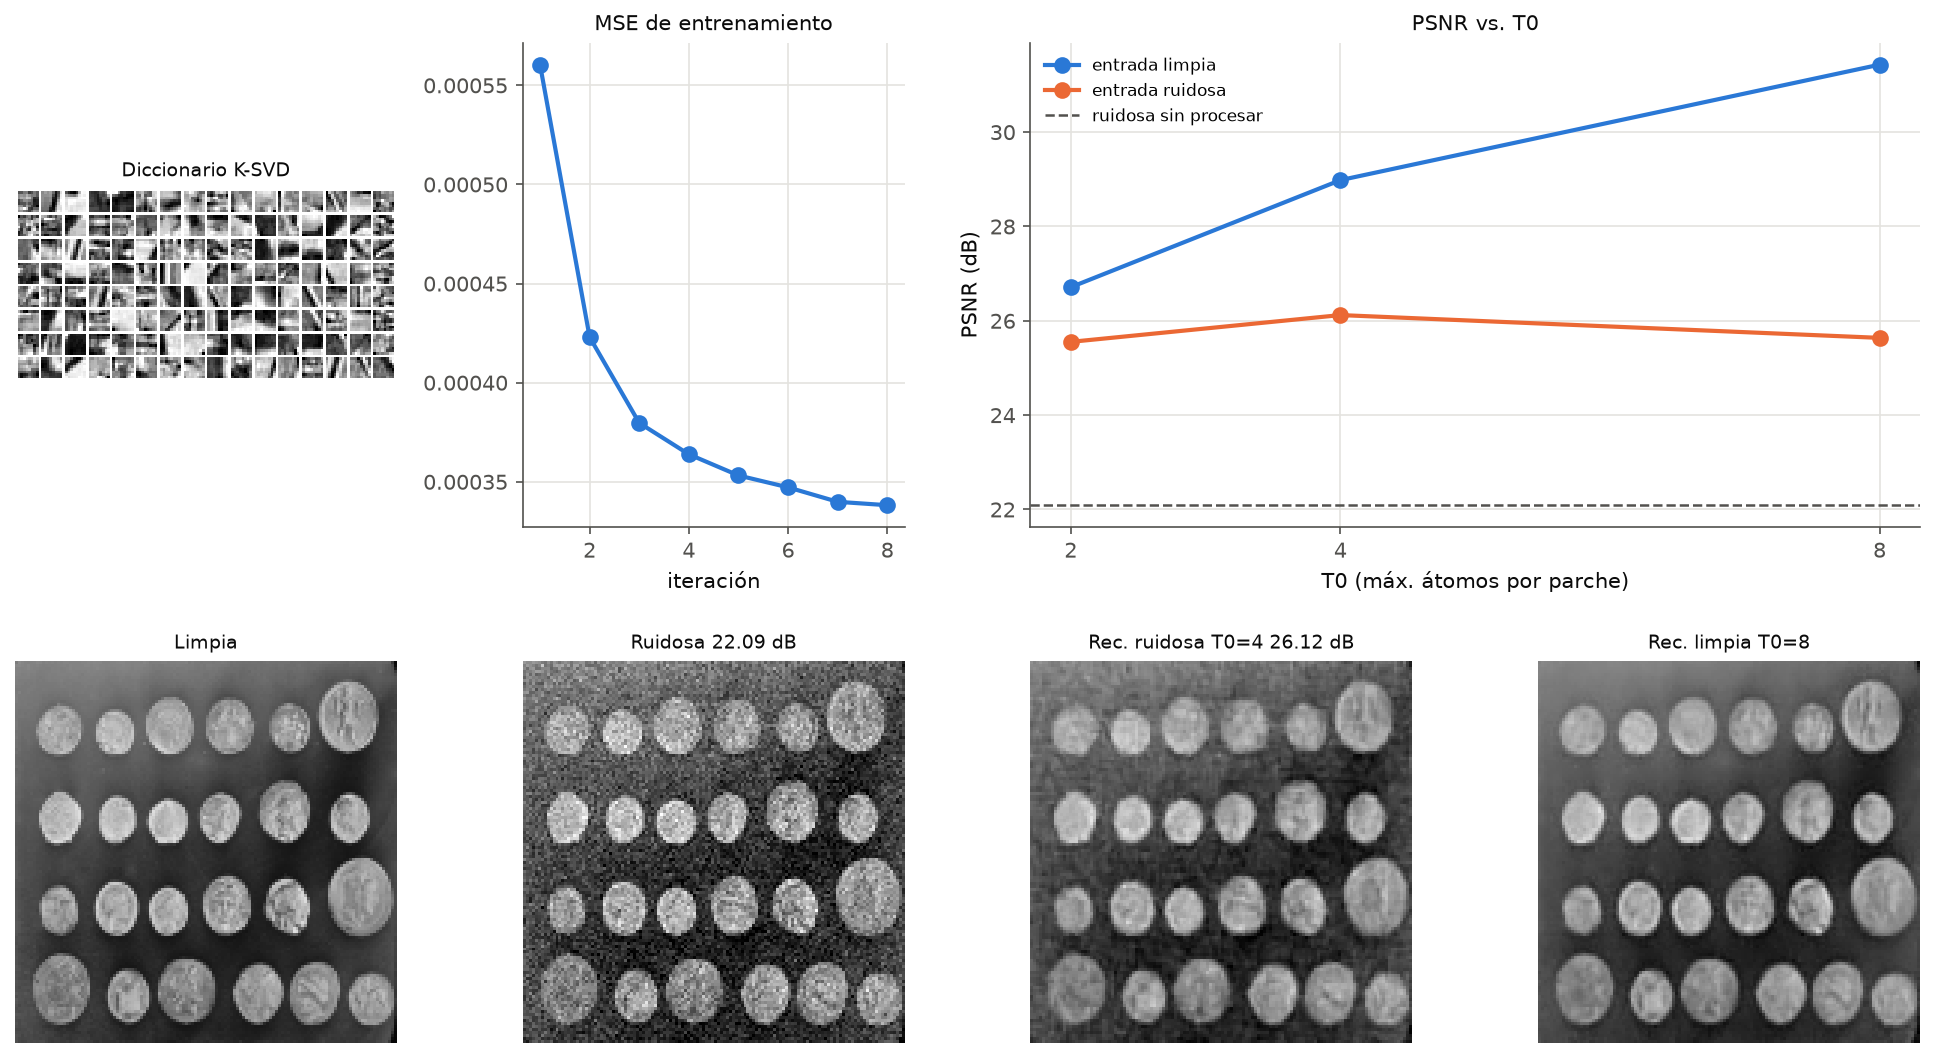

In [5]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "04_final/figuras/resumen_resultados.png")))

## 5. Reporte y presentación

Se regeneran a partir de los archivos de resultados (`tools/build_report.py`). El PDF del reporte requiere `pdflatex`; si no está disponible se conserva el `.tex`/`.md`.

In [6]:
import subprocess, sys
r = subprocess.run([sys.executable, str(ROOT / "tools" / "build_report.py")], capture_output=True, text=True)
print(r.stdout[-2000:]); print(r.stderr[-2000:])

presentación: 8 diapositivas -> 04_final\presentacion\presentacion.pdf
pdflatex no disponible: se conserva reporte.tex y reporte.md


